In [4]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing libraries for machine learning and model evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    precision_score, recall_score, confusion_matrix, classification_report,
    accuracy_score, f1_score, roc_auc_score, roc_curve, auc
)

# Setting a random seed for reproducibility
np.random.seed(42)

# Loading the Fetal Health Classification dataset
df = pd.read_csv("fetal_health (1).csv")

# Displaying the first few rows of the dataset to understand its structure
print(data.head())

   baseline value  accelerations  fetal_movement  uterine_contractions  \
0           120.0          0.000             0.0                 0.000   
1           132.0          0.006             0.0                 0.006   
2           133.0          0.003             0.0                 0.008   
3           134.0          0.003             0.0                 0.008   
4           132.0          0.007             0.0                 0.008   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0                0.000                   0.0                       0.0   
1                0.003                   0.0                       0.0   
2                0.003                   0.0                       0.0   
3                0.003                   0.0                       0.0   
4                0.000                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variability  \
0                             73.0

In [11]:
df.info

<bound method DataFrame.info of       baseline value  accelerations  fetal_movement  uterine_contractions  \
0              120.0          0.000           0.000                 0.000   
1              132.0          0.006           0.000                 0.006   
2              133.0          0.003           0.000                 0.008   
3              134.0          0.003           0.000                 0.008   
4              132.0          0.007           0.000                 0.008   
...              ...            ...             ...                   ...   
2121           140.0          0.000           0.000                 0.007   
2122           140.0          0.001           0.000                 0.007   
2123           140.0          0.001           0.000                 0.007   
2124           140.0          0.001           0.000                 0.006   
2125           142.0          0.002           0.002                 0.008   

      light_decelerations  severe_decelerat

In [12]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


In [13]:
print("Class Distribution:")
print(data['fetal_health'].value_counts())

Class Distribution:
1.0    1655
2.0     295
3.0     176
Name: fetal_health, dtype: int64


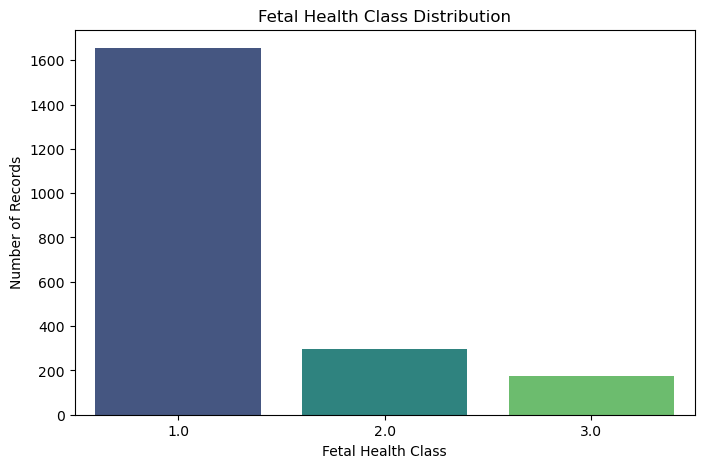

In [14]:
plt.figure(figsize=(8, 5))  # Set the figure size for better readability
sns.countplot(x='fetal_health', data=data, palette='viridis')  # Create a count plot with a color palette

# Adding plot titles and axis labels
plt.title('Fetal Health Class Distribution')  # Plot title
plt.xlabel('Fetal Health Class')  # X-axis label
plt.ylabel('Number of Records')  # Y-axis label

plt.show() 

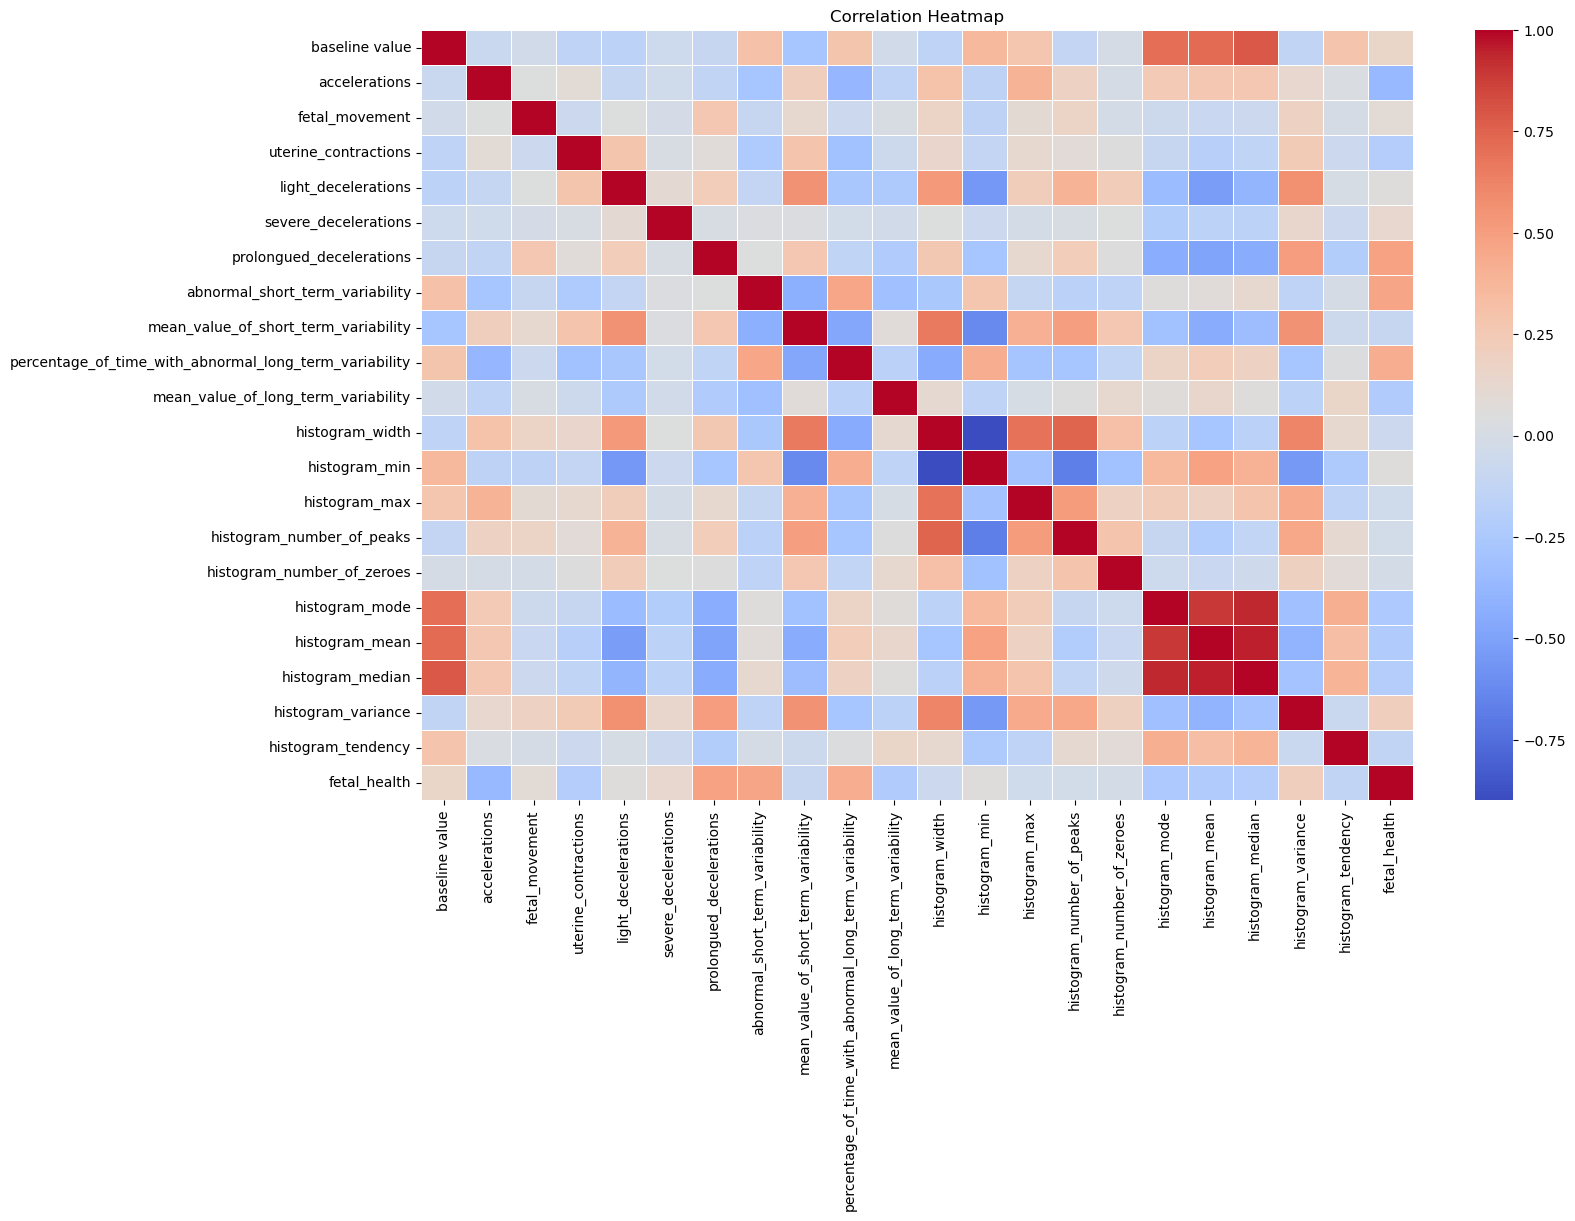

In [15]:
plt.figure(figsize=(16, 10))  # Set the figure size
correlation_matrix = data.corr()  # Compute the correlation matrix
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)  # Create the heatmap
plt.title('Correlation Heatmap')  # Add a title
plt.show()  # Display the plot

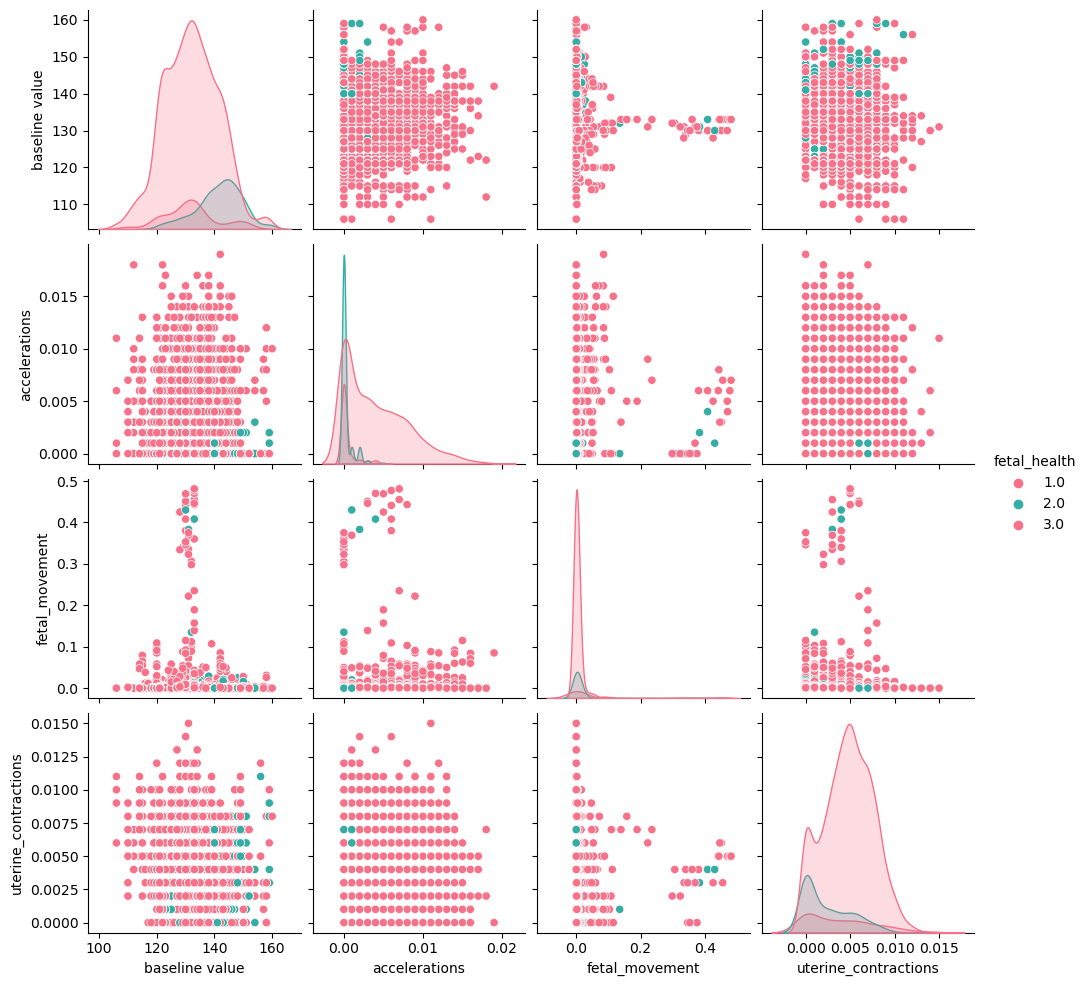

In [16]:
# Visualizing pairwise relationships among selected features
selected_features = ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'fetal_health']
sns.pairplot(data[selected_features], hue='fetal_health', palette='husl')  # Create a pairplot with class coloring
plt.show()  # Display the plot

C:\Users\user\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-p

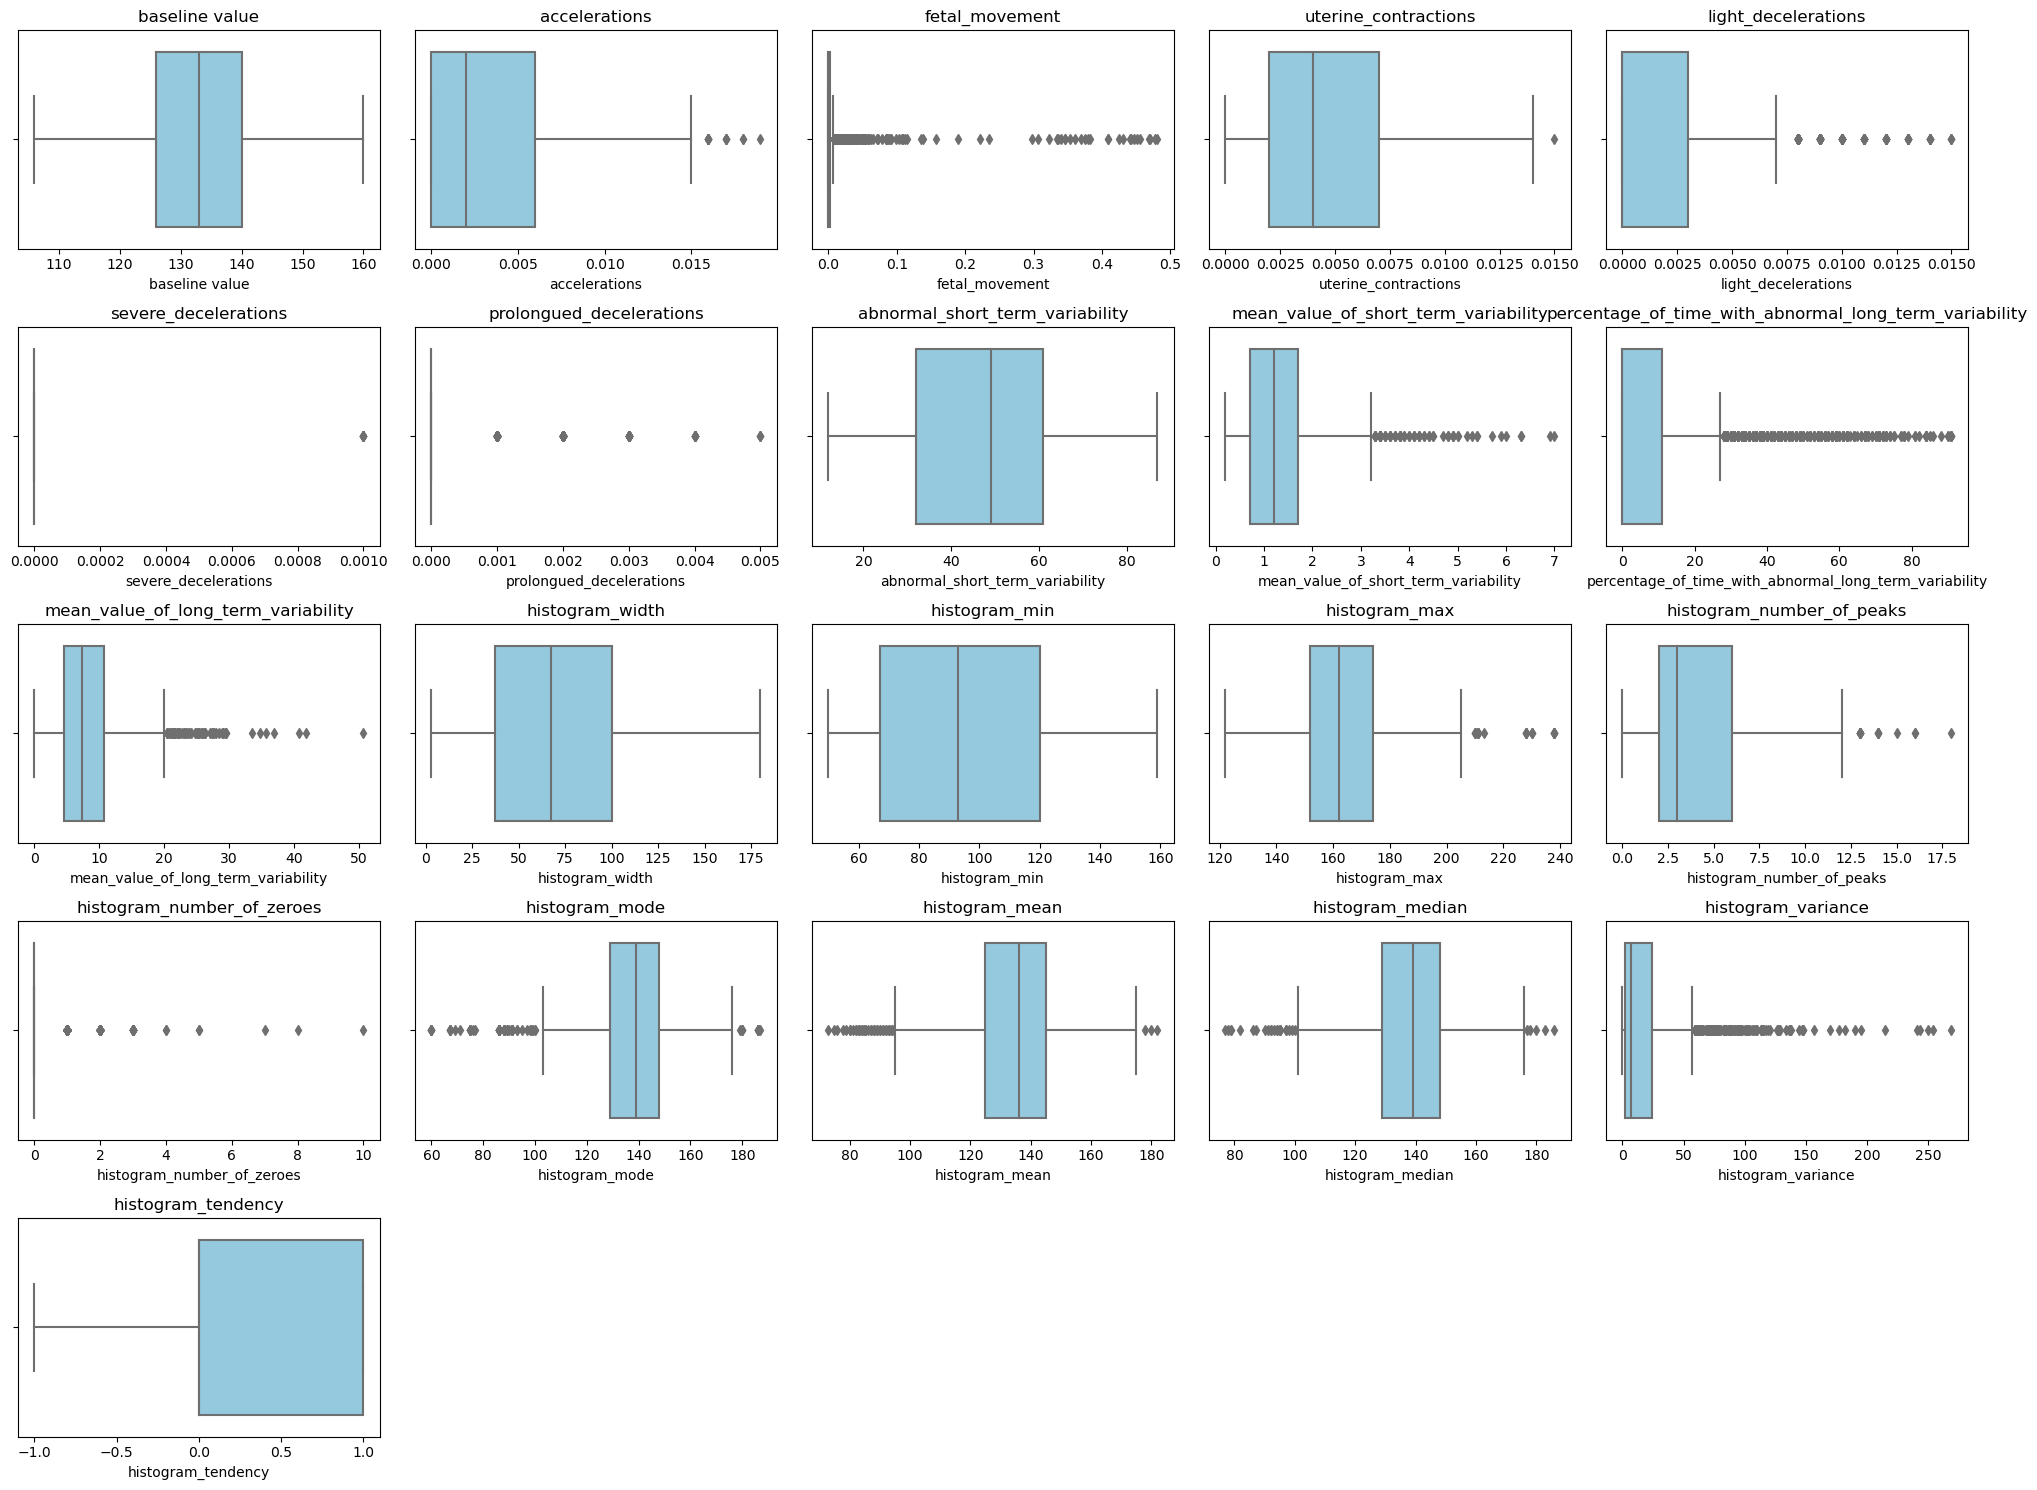

In [17]:
plt.figure(figsize=(20, 15))  # Set the figure size
for index, column in enumerate(data.columns[:-1], 1):  # Exclude the target column
    plt.subplot(5, 5, index)
    sns.boxplot(data[column], color='skyblue')  # Create a boxplot for each feature
    plt.title(column)  # Add feature name as the title
plt.tight_layout()  # Adjust layout for better readability
plt.show() 

In [18]:
missing_values = data.isnull().sum()  # Count missing values in each column
print("\nMissing Values:")
print(missing_values)


Missing Values:
baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode         

In [19]:
# Calculating the mean of each feature for each class
grouped_data = data.groupby('fetal_health').mean()
print("\nStatistical Summary for Each Class:")
print(grouped_data.T)


Statistical Summary for Each Class:
fetal_health                                                 1.0         2.0  \
baseline value                                      1.319819e+02  141.684746   
accelerations                                       3.992145e-03    0.000275   
fetal_movement                                      7.963142e-03    0.008332   
uterine_contractions                                4.780665e-03    0.002390   
light_decelerations                                 1.941390e-03    0.000536   
severe_decelerations                                6.042296e-07    0.000000   
prolongued_decelerations                            5.135952e-05    0.000095   
abnormal_short_term_variability                     4.246586e+01   61.901695   
mean_value_of_short_term_variability                1.430634e+00    0.638983   
percentage_of_time_with_abnormal_long_term_vari...  5.044713e+00   29.030508   
mean_value_of_long_term_variability                 8.705498e+00    8.026102   
his

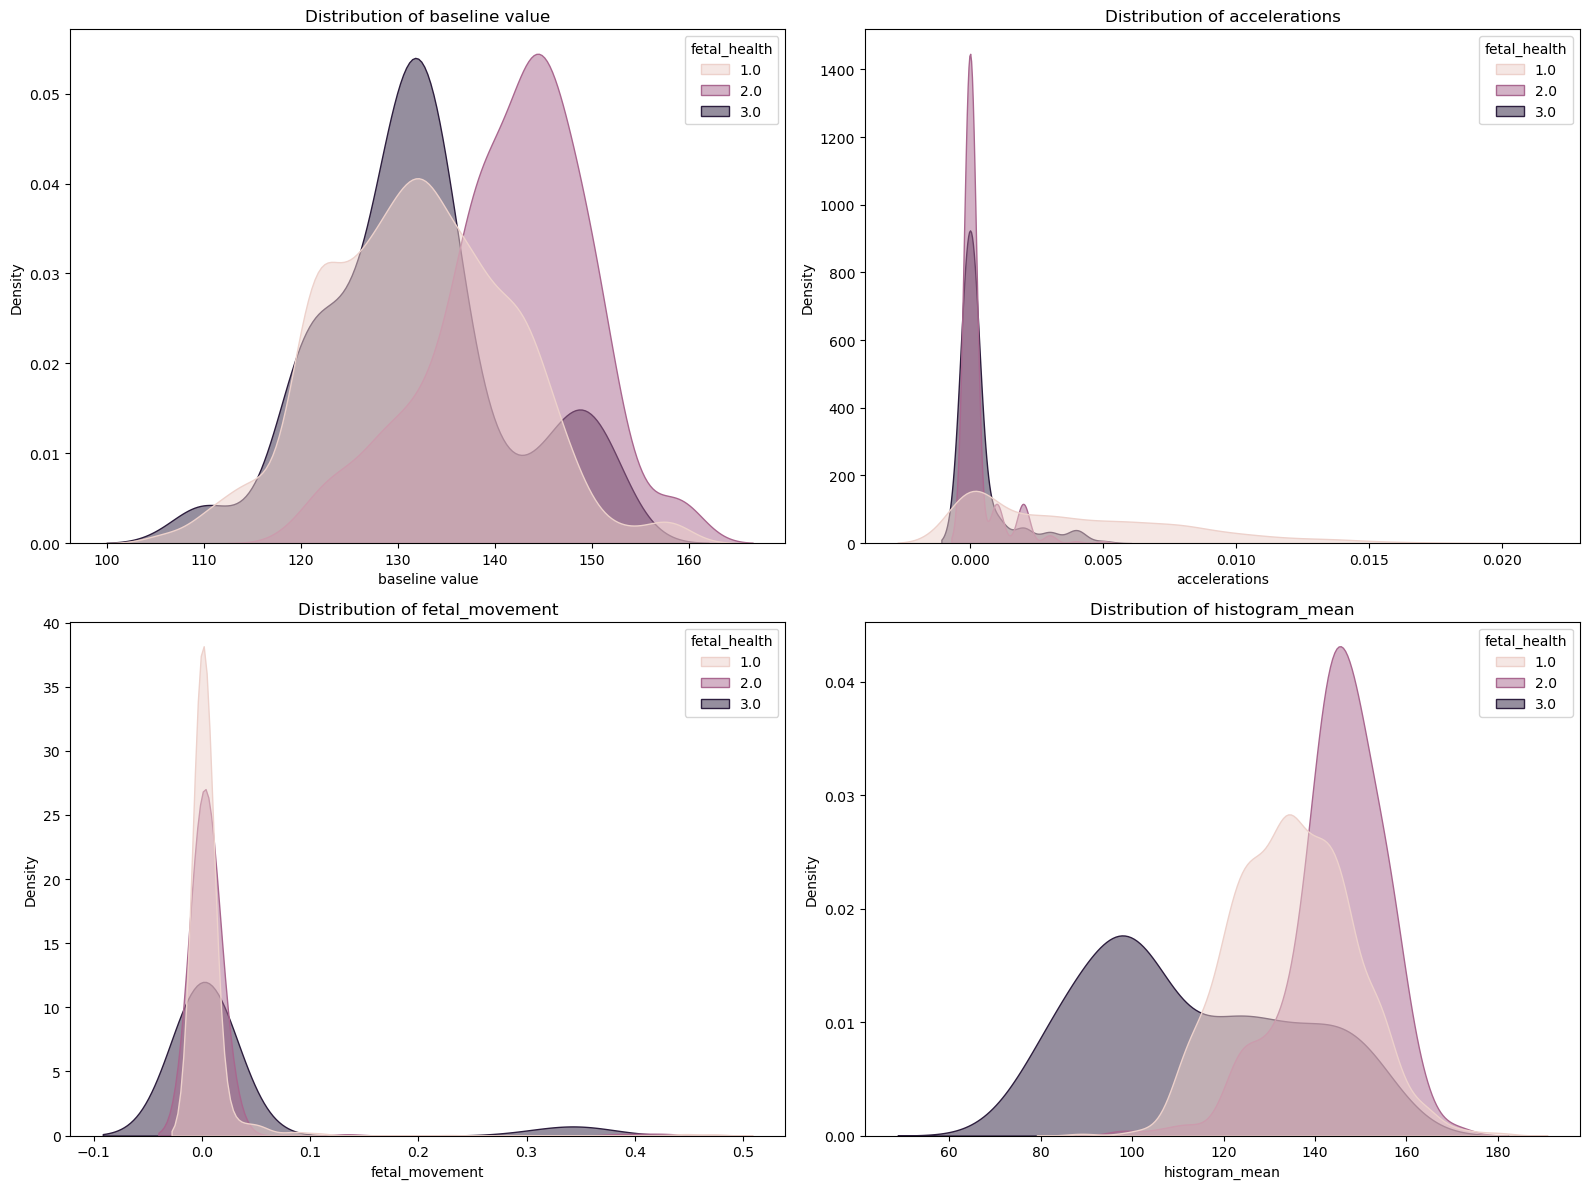

In [20]:
# Handle infinite values and missing data
data.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace infinite values with NaN
data.dropna(inplace=True)  # Drop rows with NaN

# Plotting distributions for selected features
features_to_plot = ['baseline value', 'accelerations', 'fetal_movement', 'histogram_mean']
plt.figure(figsize=(16, 12))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(
        data=data, 
        x=feature, 
        hue="fetal_health", 
        fill=True, 
        common_norm=False, 
        alpha=0.5
    )
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [21]:
# Scaling features for normalization
scaler = StandardScaler()
X = data.drop('fetal_health', axis=1)  # Features
y = data['fetal_health']  # Target variable
X_scaled = scaler.fit_transform(X)  # Apply standard scaling

In [22]:
# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [23]:
# Training the initial Random Forest model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)  # Initialize Random Forest model
model.fit(X_train, y_train)  # Train the model on the training set
y_pred = model.predict(X_test)

In [24]:
# Evaluating the baseline model's performance
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))  # Confusion matrix

print("\nClassification Report:")
print(classification_report(y_test, y_pred))  # Classification report

# Compute ROC-AUC score for multi-class classification
roc_score = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')
print(f"ROC-AUC Score: {roc_score}")

Confusion Matrix:
[[326   6   1]
 [ 13  50   1]
 [  1   1  27]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       333
         2.0       0.88      0.78      0.83        64
         3.0       0.93      0.93      0.93        29

    accuracy                           0.95       426
   macro avg       0.92      0.90      0.91       426
weighted avg       0.94      0.95      0.94       426

ROC-AUC Score: 0.9855745685829805


In [25]:
# Hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}


In [26]:
optimized_rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
optimized_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [27]:
# Making predictions with the optimized model
y_pred = optimized_rf.predict(X_test)
y_pred_proba = optimized_rf.predict_proba(X_test)  # Probabilities for ROC-AUC calculation

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))  # Confusion matrix

print("\nClassification Report:")
print(classification_report(y_test, y_pred))  # Classification report

# Compute ROC-AUC score for multi-class classification
roc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"ROC-AUC Score: {roc_score}")

Confusion Matrix:
[[327   5   1]
 [ 11  52   1]
 [  1   1  27]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       333
         2.0       0.90      0.81      0.85        64
         3.0       0.93      0.93      0.93        29

    accuracy                           0.95       426
   macro avg       0.93      0.91      0.92       426
weighted avg       0.95      0.95      0.95       426

ROC-AUC Score: 0.9867802486938887


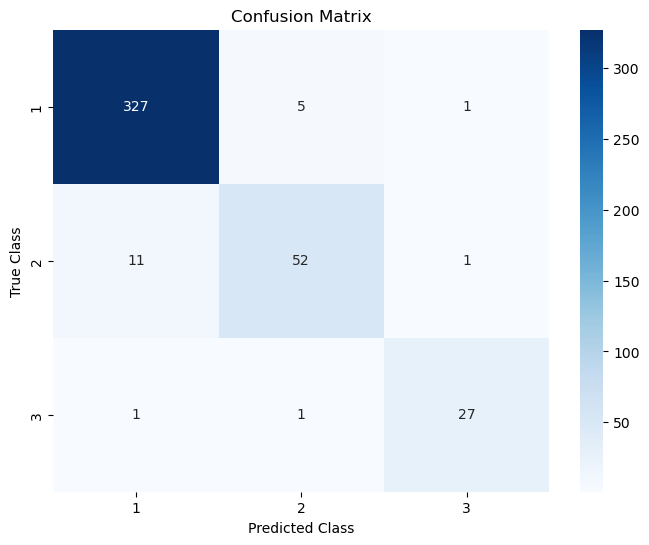

In [29]:
# Plotting the confusion matrix as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

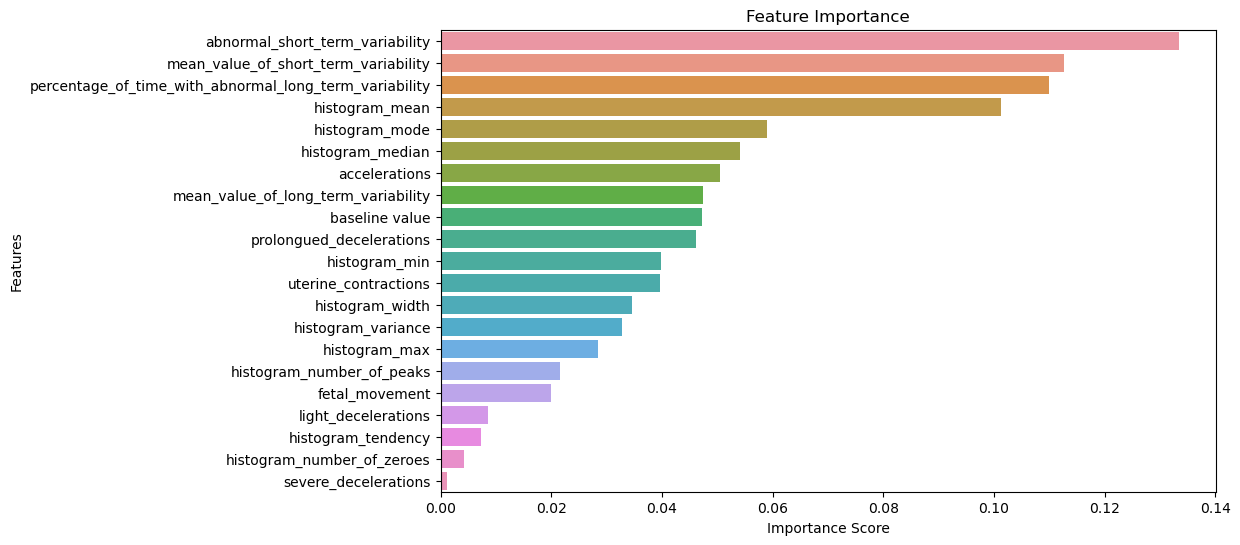

In [30]:
# Visualizing feature importance
feature_importances = pd.Series(optimized_rf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()